In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Load extraction_export as df1 and refined_export as df2
df1 = pd.read_csv("../thesis_modularized/data/extraction_export.csv", )
df2 = pd.read_csv("../thesis_modularized/data/refined_export.csv", )

In [16]:
# Removing the index row
df2.drop('Unnamed: 0', axis=1, inplace=True)
df2.head()

,ERAIL Occurrence,model_type,LLM_Date,Date of occurrence,Date_Match,LLM_Time,Time of occurrence,Time_Match,LLM_Country,Country,...,AccidentType_Match,LLM_RegulatoryBody,Reporting Body,RegulatoryBody_Match,LLM_ContributingFactor,"Direct cause description (including causal and contributing factors, excluding those of systemic nature)",ContributingFactors_Match,LLM_SystemicFactor,"Underlying and root causes description (i.e. systemic factors, if any)",SystemicFactors_Match
0,AT-0038,gemini-2.5-pro,21/03/2012,21/03/2012,Match,09:42,00:00,Mismatch,Austria,Austria,...,Mismatch,Sicherheitsuntersuchungsstelle des Bundes – Sc...,Bundesanstalt für Verkehr Unfalluntersuchung F...,Mismatch,Awareness,Disregard of the rules on the behavior at leve...,Mismatch,NaN,NaN,Match (Both Missing)
1,AT-0038,gemini-2.5-pro,21/03/2012,21/03/2012,Match,09:42,00:00,Mismatch,Österreich,Austria,...,Mismatch,Sicherheitsuntersuchungsstelle des Bundes – Sc...,Bundesanstalt für Verkehr Unfalluntersuchung F...,Mismatch,Awareness,Disregard of the rules on the behavior at leve...,Mismatch,NaN,NaN,Match (Both Missing)
2,AT-0038,gpt-4o-mini,21/03/2012,21/03/2012,Match,09:42,00:00,Mismatch,Austria,Austria,...,Mismatch,Landeshauptmann von Kärnten,Bundesanstalt für Verkehr Unfalluntersuchung F...,Mismatch,Fatigue,Disregard of the rules on the behavior at leve...,Mismatch,Monitoring,NaN,ERAIL_Data_Missing
3,AT-0038,gpt-4o-mini,21/03/2012,21/03/2012,Match,09:42,00:00,Mismatch,Austria,Austria,...,Mismatch,Österreichische Bundesbahnen,Bundesanstalt für Verkehr Unfalluntersuchung F...,Mismatch,Reinforcement,Disregard of the rules on the behavior at leve...,Mismatch,Actions to address risks,NaN,ERAIL_Data_Missing
4,AT-0039,gemini-2.5-pro,02/03/2012,02/03/2012,Match,11:47,11:47,Match,Austria,Austria,...,Mismatch,Sicherheitsuntersuchungsstelle des Bundes – Sc...,Bundesanstalt für Verkehr Unfalluntersuchung F...,Mismatch,Reinforcement,Disregard of the rules on the behavior at leve...,Mismatch,Safety objectives and planning,NaN,ERAIL_Data_Missing


<Figure size 1400x600 with 0 Axes>

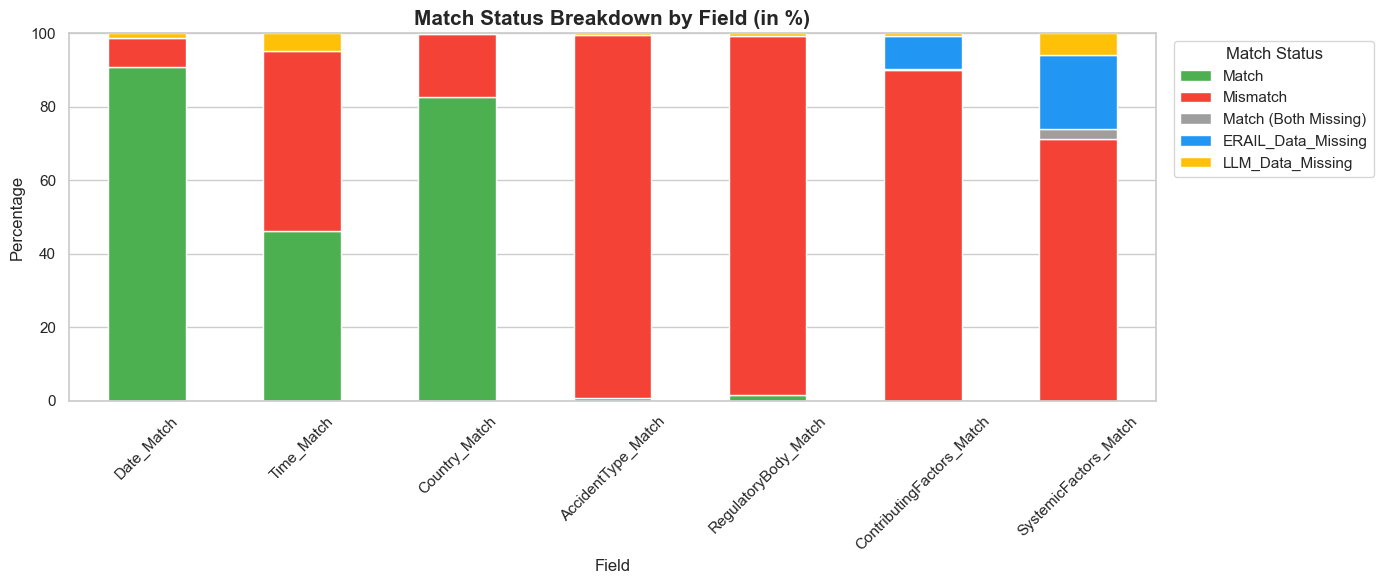

In [17]:
# Prepare match-related columns
match_columns = [
    'Date_Match', 'Time_Match', 'Country_Match', 'AccidentType_Match',
    'RegulatoryBody_Match', 'ContributingFactors_Match', 'SystemicFactors_Match'
]

# Count matches and mismatches for each column
match_stats = {col: df2[col].value_counts() for col in match_columns}
match_df2_full = pd.DataFrame(match_stats).fillna(0).astype(int).T

# Define custom hex colors for each match status
custom_colors = {
    'Match': '#4CAF50',
    'Mismatch': '#F44336',
    'Match (Both Missing)': '#9E9E9E',
    'ERAIL_Data_Missing': '#2196F3',
    'LLM_Data_Missing': '#FFC107'
}

# Ensure consistent order of columns for color mapping
ordered_statuses = [status for status in custom_colors if status in match_df2_full.columns]

# Plot using seaborn
sns.set_theme(style="whitegrid", palette=None)

# Normalize values by row to convert counts to percentages
match_df2_percent = match_df2_full[ordered_statuses].div(match_df2_full.sum(axis=1), axis=0) * 100

# Plot with custom color mapping and percentage y-axis
plt.figure(figsize=(14, 6))
match_df2_percent.plot(
    kind='bar', 
    stacked=True, 
    color=[custom_colors[status] for status in ordered_statuses],
    figsize=(14, 6)
)
plt.title('Match Status Breakdown by Field (in %)', fontsize=15, fontweight='bold')
plt.xlabel('Field')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend(title='Match Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

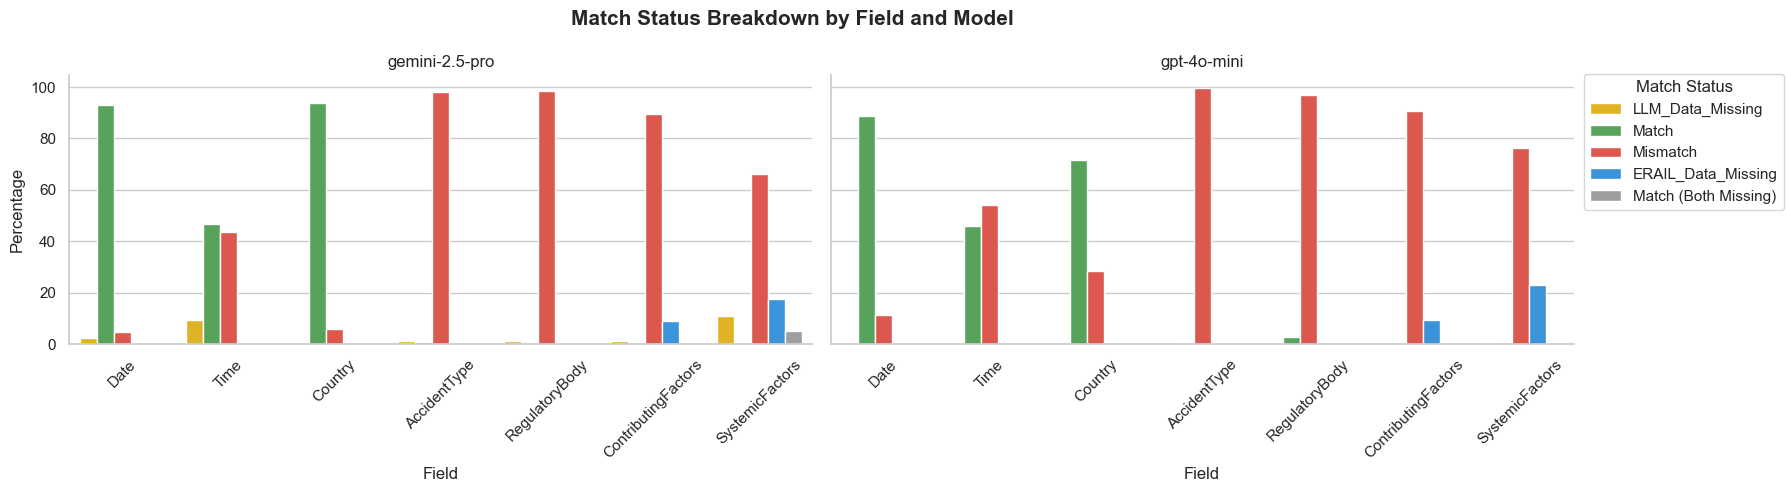

In [18]:
# Create a new dataframe with match statuses per model_type and field
model_match_stats = []

for col in match_columns:
    field_name = col.replace('_Match', '')
    grouped = df2.groupby(['model_type', col]).size().unstack(fill_value=0)
    for model in grouped.index:
        total = grouped.loc[model].sum()
        for status in grouped.columns:
            model_match_stats.append({
                'Model': model,
                'Field': field_name,
                'Status': status,
                'Percentage': (grouped.loc[model, status] / total) * 100
            })

# Convert to DataFrame
model_match_df2 = pd.DataFrame(model_match_stats)

# Filter to only known statuses with assigned colors
model_match_df2 = model_match_df2[model_match_df2['Status'].isin(custom_colors.keys())]

# Plot with seaborn
g = sns.catplot(
    data=model_match_df2,
    kind="bar",
    x="Field", y="Percentage", hue="Status",
    col="Model",
    height=5, aspect=1.4,
    palette=custom_colors,
    sharey=True
)

# Adjust titles and axis
g.set_titles("{col_name}")
g.set_axis_labels("Field", "Percentage")
g.set_xticklabels(rotation=45)

# Move the legend to the right side of the second plot
g._legend.set_title("Match Status")
g._legend.set_bbox_to_anchor((1.12, 0.7))
g._legend.set_frame_on(True)

# Adjust layout and main title
g.figure.subplots_adjust(top=0.85, right=0.85)
g.figure.suptitle("Match Status Breakdown by Field and Model", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

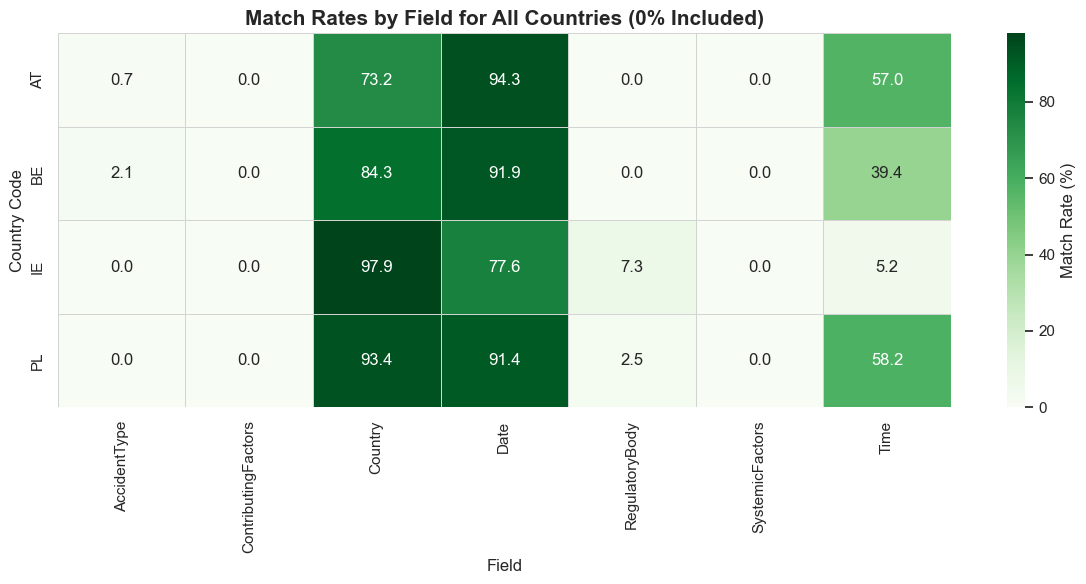

In [ ]:
df2["Country_Code"] = df2["ERAIL Occurrence"].str.extract(r"^([A-Z]{2})")

match_columns = [
    'Date_Match', 'Time_Match', 'Country_Match',
    'AccidentType_Match', 'RegulatoryBody_Match',
    'ContributingFactors_Match', 'SystemicFactors_Match'
]

melted_by_code = df2.melt(
    id_vars=["Country_Code"],
    value_vars=match_columns,
    var_name="Field",
    value_name="Match_Status"
)

melted_by_code["Field"] = melted_by_code["Field"].str.replace("_Match", "")
all_fields = melted_by_code["Field"].unique()
all_countries = melted_by_code["Country_Code"].unique()

full_index = pd.MultiIndex.from_product(
    [all_countries, all_fields],
    names=["Country_Code", "Field"]
)

match_counts = (
    melted_by_code[melted_by_code["Match_Status"] == "Match"]
    .groupby(["Country_Code", "Field"])
    .size()
    .reindex(full_index, fill_value=0)
    .unstack(fill_value=0)
)

country_code_total_counts = df2["Country_Code"].value_counts()
match_rates = match_counts.div(country_code_total_counts, axis=0) * 100

plt.figure(figsize=(12, 6))
sns.set_theme(style="white", palette=None)
sns.heatmap(
    match_rates,
    cmap="Greens",
    linewidths=0.5,
    linecolor='lightgray',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': 'Match Rate (%)'}
)
plt.title("Match Rates by Field for All Countries (Normalized by Count)", fontsize=15, fontweight='bold')
plt.xlabel("Field")
plt.ylabel("Country Code")
plt.tight_layout()
plt.show()

C:\Users\drago\AppData\Local\Temp\ipykernel_15332\57376415.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


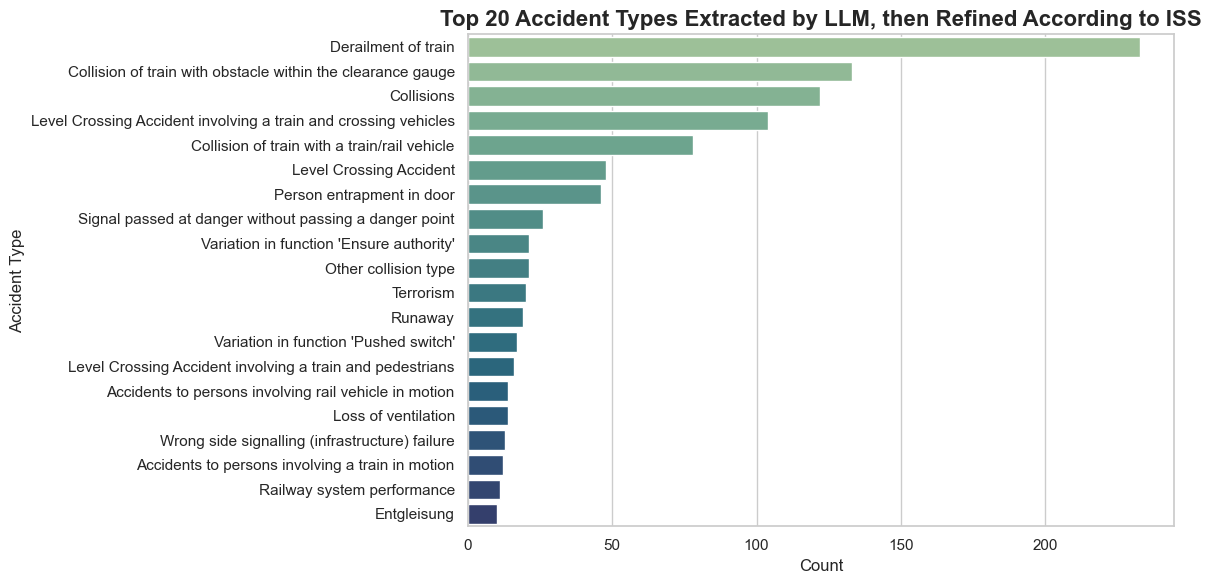

In [20]:
# Count the top 20 most frequent LLM-extracted accident types
top_20_accident_types = (
    df2['LLM_AccidentType']
    .dropna()
    .value_counts()
    .head(20)
)

# Plot bar chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    y=top_20_accident_types.index,
    x=top_20_accident_types.values,
    palette="crest"
)
plt.title("Top 20 Accident Types Extracted by LLM, then Refined According to ISS", fontsize=16, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Accident Type")
plt.tight_layout()
plt.show()

C:\Users\drago\AppData\Local\Temp\ipykernel_15332\4057416661.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


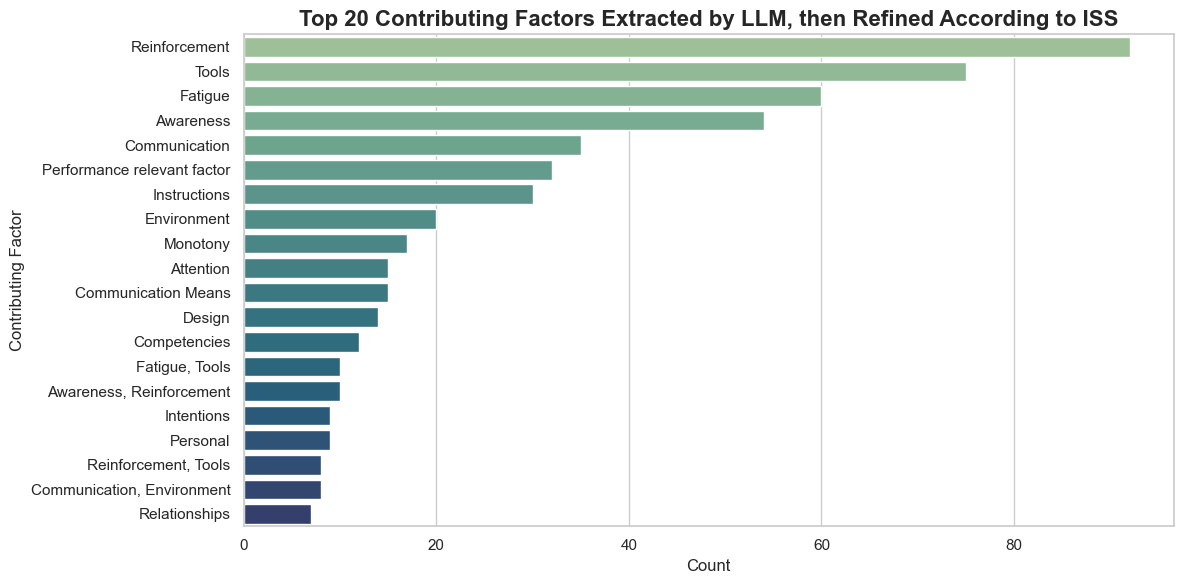

In [21]:
# Count the top 20 most frequent LLM-extracted contributing factors
top_20_contributing_factors = (
    df2['LLM_ContributingFactor']
    .dropna()
    .value_counts()
    .head(20)
)

# Plot bar chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    y=top_20_contributing_factors.index,
    x=top_20_contributing_factors.values,
    palette="crest"
)
plt.title("Top 20 Contributing Factors Extracted by LLM, then Refined According to ISS", fontsize=16, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Contributing Factor")
plt.tight_layout()
plt.show()

C:\Users\drago\AppData\Local\Temp\ipykernel_15332\3308346187.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


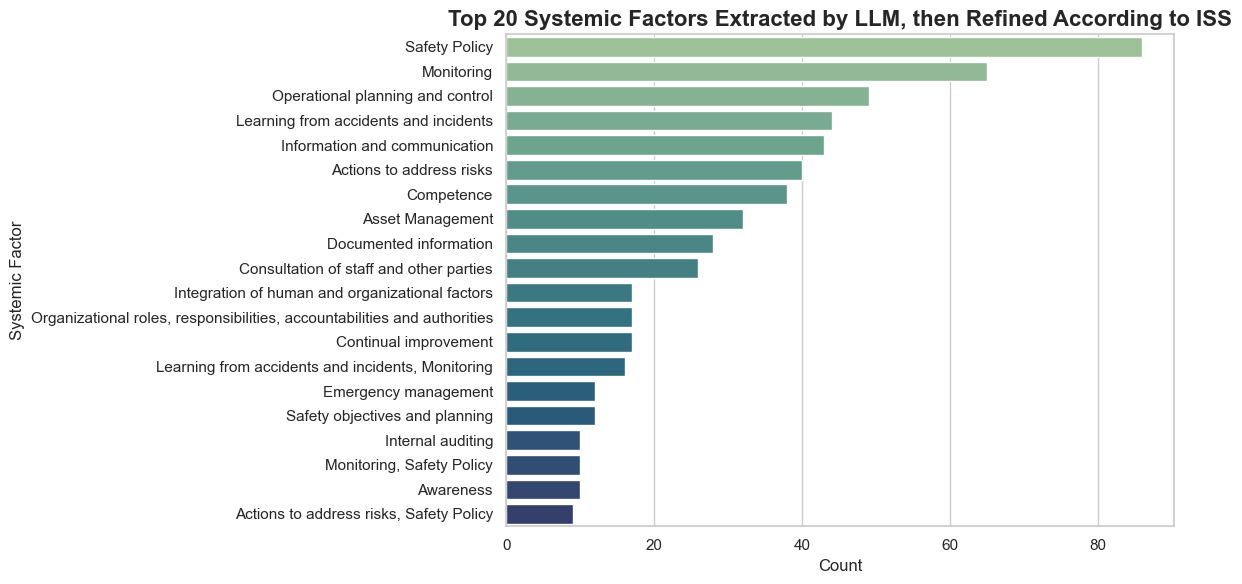

In [22]:
# Count the top 20 most frequent LLM-extracted systemic factors
top_20_systemic_factors = (
    df2['LLM_SystemicFactor']
    .dropna()
    .value_counts()
    .head(20)
)

# Plot bar chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    y=top_20_systemic_factors.index,
    x=top_20_systemic_factors.values,
    palette="crest"
)
plt.title("Top 20 Systemic Factors Extracted by LLM, then Refined According to ISS", fontsize=16, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Systemic Factor")
plt.tight_layout()
plt.show()

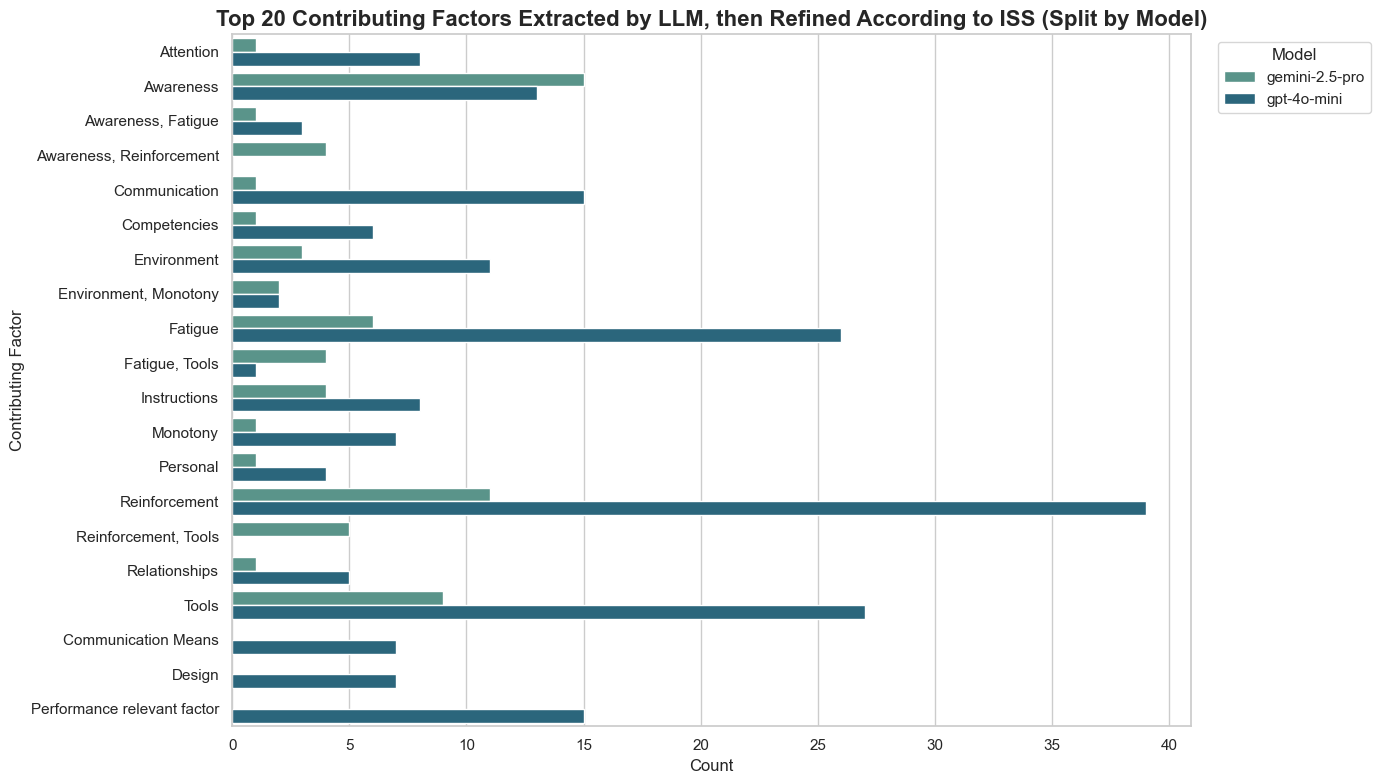

In [23]:
# Keep only the first record per ERAIL Occurrence and model_type (i.e., first iteration of models execution)
contributing_df2 = df2.drop_duplicates(subset=['ERAIL Occurrence', 'model_type'], keep='first')

# Split comma-separated contributing factors, explode, and clean
split_factors = (
    contributing_df2
    .dropna(subset=['LLM_ContributingFactor'])
    .assign(LLM_SystemicFactor=contributing_df2['LLM_ContributingFactor'].str.split(','))
    .explode('LLM_ContributingFactor')
    .assign(LLM_SystemicFactor=lambda x: x['LLM_ContributingFactor'].str.strip())
)

# Count frequency by model_type and factor
factor_counts = (
    split_factors
    .groupby(['model_type', 'LLM_ContributingFactor'])
    .size()
    .reset_index(name='count')
)

# Get top 20 contributing factors overall for filtering
top_20_factors = (
    factor_counts
    .groupby('LLM_ContributingFactor')['count']
    .sum()
    .nlargest(20)
    .index
)

filtered = factor_counts[factor_counts['LLM_ContributingFactor'].isin(top_20_factors)]

# Plot grouped bar chart
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=filtered,
    x='count',
    y='LLM_ContributingFactor',
    hue='model_type',
    palette='crest'
)
plt.title("Top 20 Contributing Factors Extracted by LLM, then Refined According to ISS (Split by Model)", fontsize=16, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Contributing Factor")
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


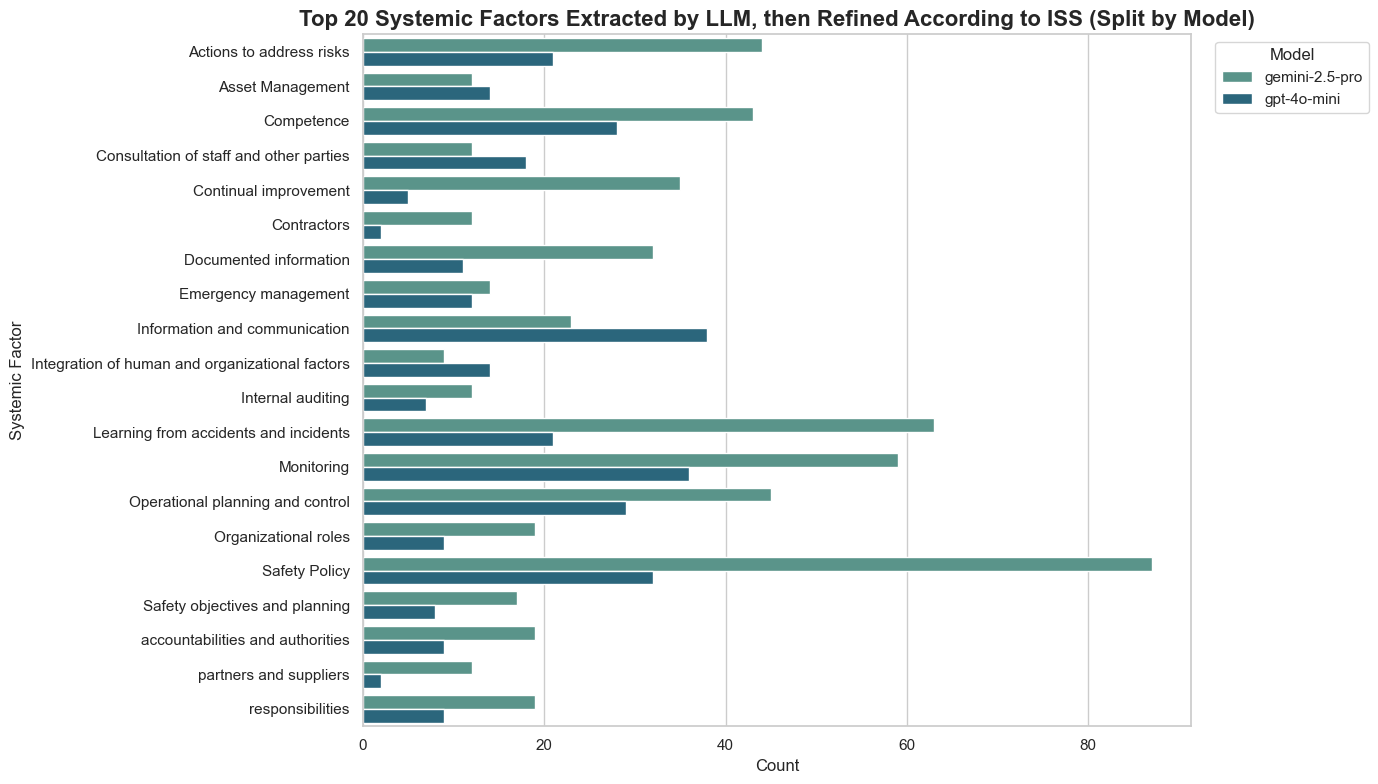

In [24]:
# Keep only the first record per ERAIL Occurrence and model_type (i.e., first iteration of models execution)
systemic_df2 = df2.drop_duplicates(subset=['ERAIL Occurrence', 'model_type'], keep='first')

# Split comma-separated systemic factors, explode, and clean
split_factors = (
    systemic_df2
    .dropna(subset=['LLM_SystemicFactor'])
    .assign(LLM_SystemicFactor=systemic_df2['LLM_SystemicFactor'].str.split(','))
    .explode('LLM_SystemicFactor')
    .assign(LLM_SystemicFactor=lambda x: x['LLM_SystemicFactor'].str.strip())
)

# Count frequency by model_type and factor
factor_counts = (
    split_factors
    .groupby(['model_type', 'LLM_SystemicFactor'])
    .size()
    .reset_index(name='count')
)

# Get top 20 systemic factors overall for filtering
top_20_factors = (
    factor_counts
    .groupby('LLM_SystemicFactor')['count']
    .sum()
    .nlargest(20)
    .index
)

filtered = factor_counts[factor_counts['LLM_SystemicFactor'].isin(top_20_factors)]

# Plot grouped bar chart
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=filtered,
    x='count',
    y='LLM_SystemicFactor',
    hue='model_type',
    palette='crest'
)
plt.title("Top 20 Systemic Factors Extracted by LLM, then Refined According to ISS (Split by Model)", fontsize=16, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Systemic Factor")
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [33]:
# Deduplication
df1_deduped = df1.drop_duplicates(subset=['ERAIL Occurrence', 'model_type'], keep='first')
df2_deduped = df2.drop_duplicates(subset=['ERAIL Occurrence', 'model_type'], keep='first')

# Extraction renaming
extraction_df_renamed = df1_deduped.rename(columns={
    'LLM_AccidentType': 'AccidentType_Extraction',
    'LLM_ContributingFactor': 'ContributingFactor_Extraction',
    'LLM_SystemicFactor': 'SystemicFactor_Extraction'
})

# Refinement renaming
refined_df_renamed = df2_deduped.rename(columns={
    'LLM_AccidentType': 'AccidentType_Refined',
    'LLM_ContributingFactor': 'ContributingFactor_Refined',
    'LLM_SystemicFactor': 'SystemicFactor_Refined'
})

# Performing merge
merged_df = pd.merge(
    extraction_df_renamed,
    refined_df_renamed,
    on=['ERAIL Occurrence', 'model_type'],
    suffixes=('_Extracted', '_Refined')
)

# Filter for changed fields
changed_rows = merged_df[
    (merged_df['AccidentType_Extraction'] != merged_df['AccidentType_Refined']) |
    (merged_df['ContributingFactor_Extraction'] != merged_df['ContributingFactor_Refined']) |
    (merged_df['SystemicFactor_Extraction'] != merged_df['SystemicFactor_Refined'])
].copy()

# Derive country code and sample examples
changed_rows['Country_Code'] = changed_rows['ERAIL Occurrence'].str[:2]
target_countries = ['AT', 'BE', 'IE', 'PL']
filtered = changed_rows[changed_rows['Country_Code'].isin(target_countries)]

examples_by_country = (
    filtered.groupby('Country_Code')
    .head(2)
    .sort_values(by='Country_Code')
)[[
    'Country_Code', 'ERAIL Occurrence', 'model_type',
    'AccidentType_Extraction', 'AccidentType_Refined',
    'ContributingFactor_Extraction', 'ContributingFactor_Refined',
    'SystemicFactor_Extraction', 'SystemicFactor_Refined'
]]

examples_by_country

,Country_Code,ERAIL Occurrence,model_type,AccidentType_Extraction,AccidentType_Refined,ContributingFactor_Extraction,ContributingFactor_Refined,SystemicFactor_Extraction,SystemicFactor_Refined
0,AT,AT-0038,gemini-2.5-pro,Collision with a passenger car at a level cros...,Level Crossing Accident involving a train and ...,Car driver crossed the level crossing despite ...,Awareness,NaN,NaN
1,AT,AT-0038,gpt-4o-mini,Collision,Collision of train with obstacle within the cl...,Driver's failure to stop at signal,Fatigue,Use of level crossing despite red signal,Monitoring
306,BE,BE-10021,gemini-2.5-pro,Derailment,Derailment of train,Cut rail section left within the clearance pro...,"Communication, Tools",Insufficient risk management for post-work tra...,"Actions to address risks, Asset Management"
307,BE,BE-10021,gpt-4o-mini,Train Derailment,Derailment of train,Improper Material Handling,Tools,Lack of Safety Protocols,Actions to address risks
424,IE,IE-0282,gemini-2.5-pro,Collision with a tractor on a level crossing,Level Crossing Accident involving a train and ...,Inadequate viewing distances at the level cros...,"Awareness, Tools, Work-rhythms",Failure to introduce adequate safety measures ...,"Actions to address risks, Emergency management..."
425,IE,IE-0282,gpt-4o-mini,Collision with Tractor,Collisions,"Poor Viewing Distances, Using Railway Signals ...","Attention, Reinforcement",Lack of Adequate Safety Measures,Actions to address risks
520,PL,PL-10018,gemini-2.5-pro,Serious accident,Assault,Driver's failure to behave with special cautio...,"Awareness, Reinforcement",NaN,NaN
521,PL,PL-10018,gpt-4o-mini,Serious accident,Assault,Driver's failure to behave with special cautio...,Reinforcement,No traffic protection systems at the crossing,Operational planning and control
